#LIBRARIES

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer,OneHotEncoder,StandardScaler
from pyspark.ml.classification import LogisticRegression,RandomForestClassifier
from pyspark.ml.regression import RandomForestRegressor,GBTRegressor
from xgboost.spark import SparkXGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,confusion_matrix,accuracy_score,ConfusionMatrixDisplay,mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from google.colab import drive
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#LOAD DATA

In [6]:
spark = SparkSession.builder.appName("ShopperIntentionModel").getOrCreate()
df=spark.read.csv('/content/drive/MyDrive/Colab Notebooks/DataSets/online_shoppers_intention.csv',header=True,inferSchema=True)
df.show()


+--------------+-----------------------+-------------+----------------------+--------------+-----------------------+-----------+-----------+----------+----------+-----+----------------+-------+------+-----------+-----------------+-------+-------+
|Administrative|Administrative_Duration|Informational|Informational_Duration|ProductRelated|ProductRelated_Duration|BounceRates|  ExitRates|PageValues|SpecialDay|Month|OperatingSystems|Browser|Region|TrafficType|      VisitorType|Weekend|Revenue|
+--------------+-----------------------+-------------+----------------------+--------------+-----------------------+-----------+-----------+----------+----------+-----+----------------+-------+------+-----------+-----------------+-------+-------+
|             0|                    0.0|            0|                   0.0|             1|                    0.0|        0.2|        0.2|       0.0|       0.0|  Feb|               1|      1|     1|          1|Returning_Visitor|  false|  false|
|           

#NORMALIZING

In [7]:


month_indexer = StringIndexer(inputCol='Month', outputCol='month_indexer',handleInvalid='keep')
visitor_indexer = StringIndexer(inputCol='VisitorType', outputCol='visitor_indexer',handleInvalid='keep')
ope_indexer = StringIndexer(inputCol='OperatingSystems', outputCol='ope_indexer',handleInvalid='keep')
brow_indexer = StringIndexer(inputCol='Browser', outputCol='brow_indexer',handleInvalid='keep')
region_indexer = StringIndexer(inputCol='Region', outputCol='region_indexer',handleInvalid='keep')
tra_indexer = StringIndexer(inputCol='TrafficType', outputCol='tra_indexer',handleInvalid='keep')
week_indexer = StringIndexer(inputCol='Weekend', outputCol='week_indexer',handleInvalid='keep')


#Vectorization


onehotencode_month = OneHotEncoder(inputCol='month_indexer', outputCol='Month_Vector',handleInvalid='keep')
onehotencode_visitor = OneHotEncoder(inputCol='visitor_indexer', outputCol='VisitorType_Vector',handleInvalid='keep')
onehotencode_ope = OneHotEncoder(inputCol='ope_indexer', outputCol='OperatingSystems_Vector',handleInvalid='keep')
onehotencode_brow = OneHotEncoder(inputCol='brow_indexer', outputCol='Browser_Vector',handleInvalid='keep')
onehotencode_region = OneHotEncoder(inputCol='region_indexer', outputCol='Region_Vector',handleInvalid='keep')
onehotencode_tra = OneHotEncoder(inputCol='tra_indexer', outputCol='Tra_Vector',handleInvalid='keep')
onehotencode_week = OneHotEncoder(inputCol='week_indexer', outputCol='Weekend_Vector',handleInvalid='keep')


feature_columns=['Month_Vector','VisitorType_Vector','OperatingSystems_Vector','Browser_Vector','Region_Vector','Channel_Vector','Weekend_Vector']

#VECTOR ASSEMBLER

In [8]:
#vector assembler
feature_columns=['Month_Vector','VisitorType_Vector','OperatingSystems_Vector','Browser_Vector','Region_Vector','Tra_Vector', 'Weekend'] # Added Weekend back as a direct feature
assembler=VectorAssembler(inputCols=feature_columns,outputCol='features')

#NORMALIZER

In [9]:
#normalizer
scaler=StandardScaler(inputCol='features',outputCol='scaled_features')

#LOGISTICREGRESSION

In [10]:
lr=LogisticRegression(featuresCol='scaled_features',labelCol='Revenue')#logReg based Revenue with numerical features



#PIPELINE

In [11]:
pipeline = Pipeline(stages=[
    month_indexer, visitor_indexer, ope_indexer, brow_indexer,
    region_indexer, tra_indexer,week_indexer,
    onehotencode_month, onehotencode_visitor,
    onehotencode_ope, onehotencode_brow,
    onehotencode_region, onehotencode_tra,onehotencode_week,
    assembler,
    scaler,
    lr
])

#TRAIN AND TEST

In [13]:

from pyspark.sql.functions import col
df = df.withColumn("Revenue", col("Revenue").cast("double"))
df=df.withColumn("Weekend", col("Weekend").cast("integer"))


In [15]:
train_data,test_data=df.randomSplit([0.8,0.2],seed=42)
#fit
model = pipeline.fit(train_data)
predictions = model.transform(test_data)
#convert to panda

pdf = predictions.select('Revenue', 'prediction', 'probability').toPandas()
pdf['Revenue'] = pdf['Revenue'].astype(int)
pdf['prediction'] = pdf['prediction'].astype(int)

#ACCURACY

In [21]:
acc=accuracy_score(pdf['Revenue'],pdf['prediction'])
print(f"Accuracy:{acc:.2f}")

Accuracy:0.84


#CONFUSIONMATRIX

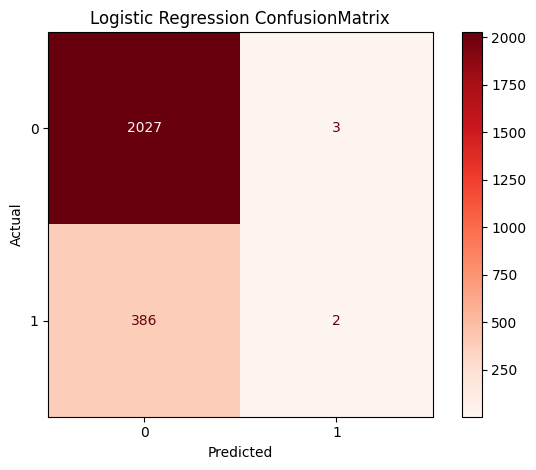

In [34]:
cm=confusion_matrix(pdf['Revenue'],pdf['prediction'])
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=[0,1])
disp.plot(cmap='Reds')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression ConfusionMatrix')
plt.tight_layout()
plt.show()


#PROBABILITY DISTRIBUTION

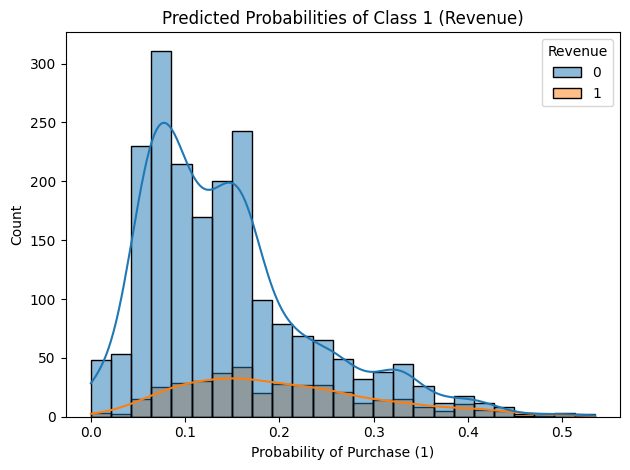

In [33]:
pdf['prob_1'] = pdf['probability'].apply(lambda x: x[1])  # Probability of class 1
sns.histplot(data=pdf, x='prob_1', hue='Revenue', bins=25, kde=True)
plt.title("Predicted Probabilities of Class 1 (Revenue)")
plt.xlabel("Probability of Purchase (1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#RANDOMFORESGT

In [27]:
rf = RandomForestRegressor(featuresCol='scaled_features', labelCol='Revenue')

In [28]:
stages = [
    month_indexer, visitor_indexer, ope_indexer, brow_indexer,
    region_indexer, tra_indexer, week_indexer,
    onehotencode_month, onehotencode_visitor,
    onehotencode_ope, onehotencode_brow,
    onehotencode_region, onehotencode_tra, onehotencode_week,
    assembler, scaler
]

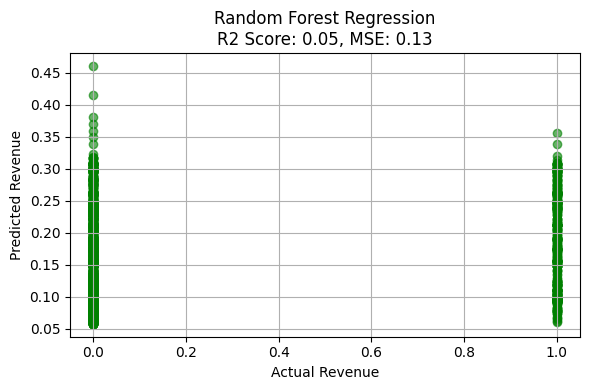

In [32]:


# Random Forest Pipeline
rf_pipeline = Pipeline(stages=stages + [rf])
rf_model = rf_pipeline.fit(train_data)
rf_predictions = rf_model.transform(test_data)

rf_pdf = rf_predictions.select('Revenue', 'prediction').toPandas()
rf_r2 = r2_score(rf_pdf['Revenue'], rf_pdf['prediction'])
rf_mse = mean_squared_error(rf_pdf['Revenue'], rf_pdf['prediction'])

plt.figure(figsize=(6, 4))
plt.scatter(rf_pdf['Revenue'], rf_pdf['prediction'], alpha=0.6, color='green')
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title(f'Random Forest Regression\nR2 Score: {rf_r2:.2f},\n MSE: {rf_mse:.2f}')
plt.grid(True)
plt.tight_layout()
plt.show()

#GRADIENTBOOSTREGRESSOR

In [37]:
gbt = GBTRegressor(featuresCol='scaled_features', labelCol='Revenue')


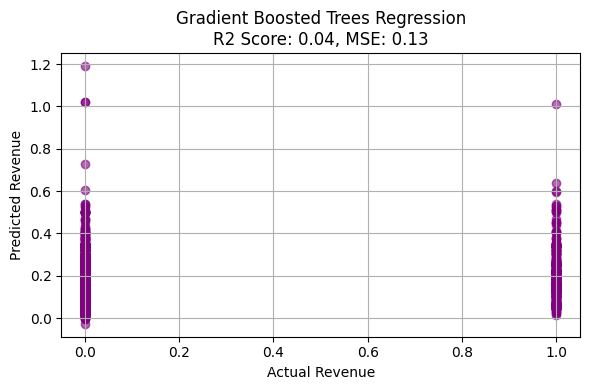

In [38]:
gbt_pipeline = Pipeline(stages=stages + [gbt])
gbt_model = gbt_pipeline.fit(train_data)
gbt_predictions = gbt_model.transform(test_data)

gbt_pdf = gbt_predictions.select('Revenue', 'prediction').toPandas()
gbt_r2 = r2_score(gbt_pdf['Revenue'], gbt_pdf['prediction'])
gbt_mse = mean_squared_error(gbt_pdf['Revenue'], gbt_pdf['prediction'])

plt.figure(figsize=(6, 4))
plt.scatter(gbt_pdf['Revenue'], gbt_pdf['prediction'], alpha=0.6, color='purple')
plt.xlabel('Actual Revenue')
plt.ylabel('Predicted Revenue')
plt.title(f'Gradient Boosted Trees Regression\nR2 Score: {gbt_r2:.2f}, MSE: {gbt_mse:.2f}')
plt.grid(True)
plt.tight_layout()
plt.show()